In [99]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path


from matplotlib.ticker import EngFormatter


In [100]:
font_size = 20

def calculate_spinnaker_energy(total_num_neurons, max_neurons_per_core, duration_seconds):
    """
    Since we use v5 Splitting, we need to calculate the core count correctly.
    MAX_NEURONS_PER_CORE = 50 is set inside the solver.
    """
    # Wadjih Bencheikh Formula
    BASE_POWER_W = 3.0
    DRAM_POWER_W = 1.536
    POWER_PER_CORE_W = 0.00719 
    
    active_cores = int(np.ceil(total_num_neurons / max_neurons_per_core))
        
    total_power_watts = BASE_POWER_W + DRAM_POWER_W + (active_cores * POWER_PER_CORE_W)
    total_energy_joules = total_power_watts * duration_seconds
    
    return total_power_watts, total_energy_joules

### Sphere Models

In [101]:
base_problem_name = "Sphere_00"
run_gammas = ["1e-3", "5e-3", "2e-2"]  # add more gamma values here

base_dir = Path.cwd()
conv_dir = base_dir / "logs_results" / "neurofem_convergence"

conv_dfs = []
for gamma in run_gammas:
    file_base_problem = f"{base_problem_name}_chipconvergence"
    file_base_name = f"{file_base_problem}_gamma{str(gamma)}"
    filename = f"{file_base_name}.txt"
    conv_path = conv_dir / filename
    if not conv_path.is_file():
        # Fallback: look in logs_results if subfolder is empty or file is missing
        fallback_path = base_dir / "logs_results" / filename
        if fallback_path.is_file():
            conv_path = fallback_path
        else:
            raise FileNotFoundError(f"Convergence file not found: {conv_path}")
    df = pd.read_csv(conv_path)
    df["gamma"] = gamma
    conv_dfs.append(df)

df_conv_all = pd.concat(conv_dfs, ignore_index=True)
df_conv_all.head()

,timestep,rel_error,gamma
0,1,1.000000,1e-3
1,200,0.971730,1e-3
2,400,0.909646,1e-3
3,600,0.830172,1e-3
4,800,0.769313,1e-3


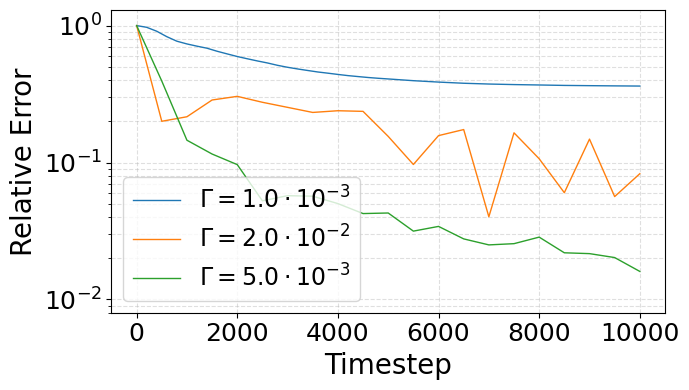

In [102]:
savefig = True

plt.figure(figsize=(7, 4))
for gamma, df_g in df_conv_all.groupby("gamma"):
    gamma_val = float(gamma)  # convert string -> float

    # now safe to use scientific notation
    gamma_latex = rf"{gamma_val:.1e}"       # e.g., 1.0e-3
    base, exp = gamma_latex.split("e")
    gamma_latex = rf"{base} \cdot 10^{{{int(exp)}}}"

    plt.semilogy(
        df_g["timestep"],
        df_g["rel_error"],
        linewidth=1,
        label=rf"$\Gamma={gamma_latex}$"
    )

plt.ylim(8e-3, 1.3)
plt.xlabel("Timestep", fontsize=font_size)
plt.ylabel("Relative Error", fontsize=font_size)
plt.tick_params(axis="both", which="major", labelsize=font_size-2)
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(fontsize=font_size-3)

plt.tight_layout()

if savefig:
    # wanted to use svg but does not work in google slides
    plt.savefig(f"figures/{file_base_problem}.png")

plt.show()

# GPU vs Spinnaker2 discussion

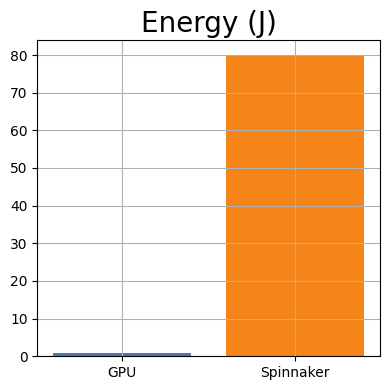

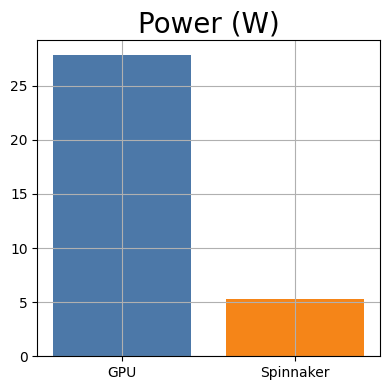

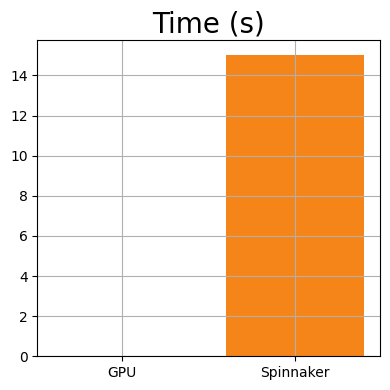

In [117]:
savefig_comparison = True

# Collected from solve
gpu_enery, gpu_watt = 0.753, 27.8
spinnaker_watt, spinnaker_joules = calculate_spinnaker_energy(total_num_neurons=28000, max_neurons_per_core=16 * 16, duration_seconds=15)
gpu_time = 0.027093
spinnaker_time = 15

# Energy comparison
plt.figure(figsize=(4, 4))
plt.bar(["GPU", "Spinnaker"], [gpu_enery, spinnaker_joules], color=["#4C78A8", "#F58518"])
plt.title("Energy (J)", fontsize=font_size)
plt.grid()
plt.tight_layout()
plt.savefig("figures/EnergyJoulesGPUVSSpinnaker.png")
plt.show()



# Power comparison
plt.figure(figsize=(4, 4))
plt.bar(["GPU", "Spinnaker"], [gpu_watt, spinnaker_watt], color=["#4C78A8", "#F58518"])
plt.title("Power (W)", fontsize=font_size)
plt.grid()
plt.tight_layout()
plt.savefig("figures/PowerWattGPUVSSpinnaker.png")
plt.show()

# Time comparison
plt.figure(figsize=(4, 4))
plt.bar(["GPU", "Spinnaker"], [gpu_time, spinnaker_time], color=["#4C78A8", "#F58518"])
plt.title("Time (s)", fontsize=font_size)
plt.grid()
plt.tight_layout()
plt.savefig("figures/SolveTime.png")
plt.show()